## Visualisation et corrélations – Introduction

À cette étape, je cherche à explorer visuellement mon jeu de données pour mieux comprendre sa structure interne.  
J’inspecte d’abord la distribution des classes pour vérifier l’équilibre du jeu, puis j’utilise des visualisations croisées (pairplot, heatmap) afin de repérer des tendances, des séparations naturelles entre classes, ou encore des variables fortement corrélées qui pourraient guider mon choix lors de l’ACP et de la sélection automatique.


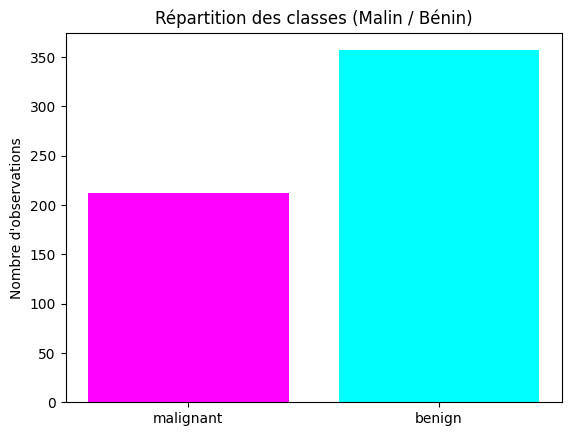

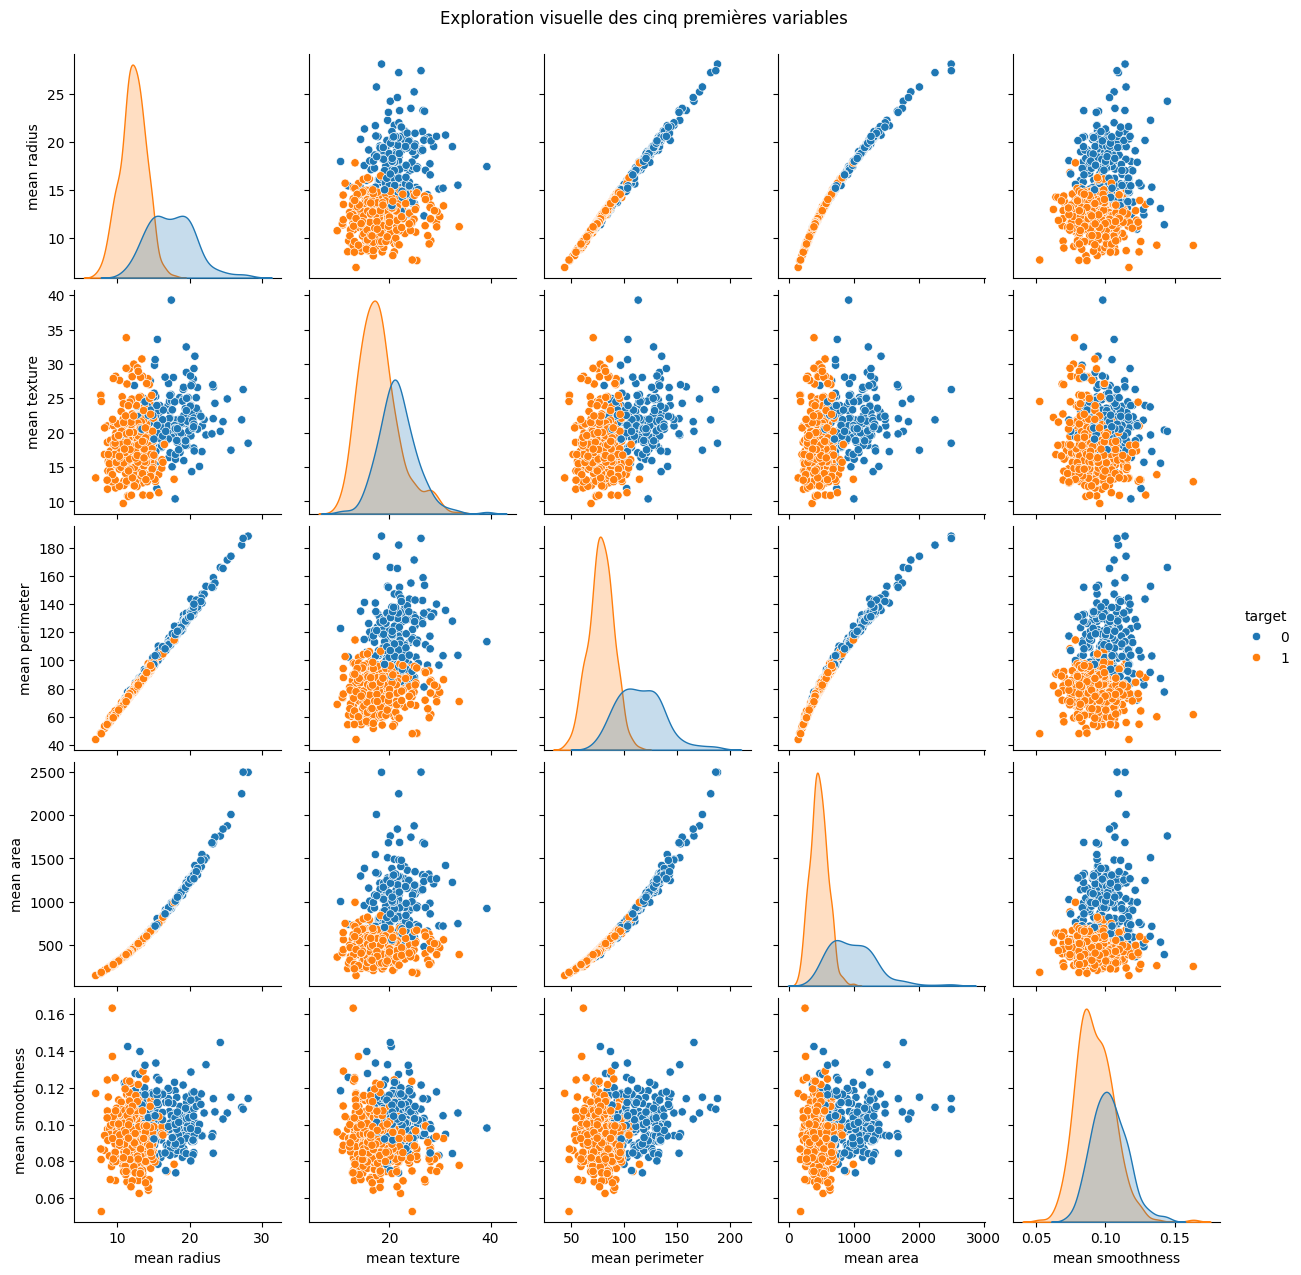

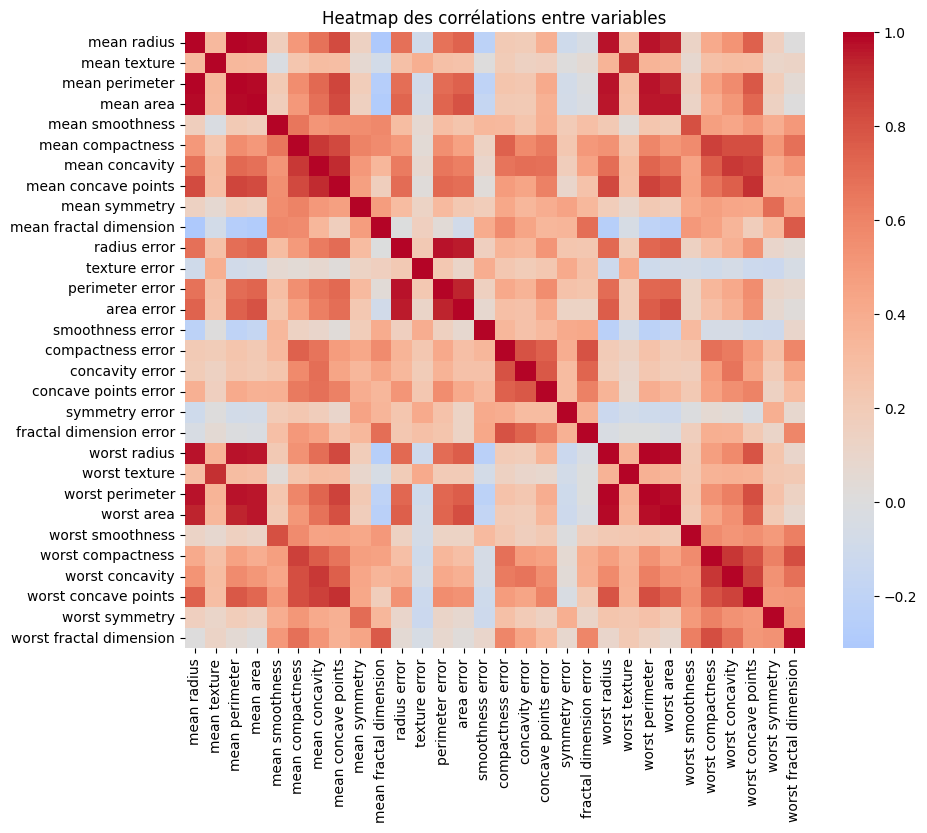

In [2]:
# 1. Import des librairies utiles pour la visualisation et le traitement
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# 2. Chargement du jeu de données Breast Cancer Wisconsin
# Ici j'utilise sklearn pour obtenir un dataset déjà propre et bien structuré
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Je transforme le tout en DataFrame Pandas pour faciliter la manipulation et la visualisation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# 3. Tracer la distribution des classes pour vérifier l'équilibre
# J'utilise np.bincount pour compter les instances de chaque classe
plt.bar(data.target_names, np.bincount(y), color=['magenta', 'cyan'])
plt.title('Répartition des classes (Malin / Bénin)')
plt.ylabel('Nombre d\'observations')
plt.show()

# 4. Visualisation croisée des cinq premières variables pour explorer les relations et la séparation entre classes
# Un pairplot permet de voir d'un coup d'œil la séparation potentielle des classes et les éventuelles outliers
sns.pairplot(df.iloc[:, :5].join(df['target']), hue='target')
plt.suptitle("Exploration visuelle des cinq premières variables", y=1.02)
plt.show()

# 5. Heatmap des corrélations entre les variables
# Cette étape m'aide à voir quelles variables sont redondantes ou fortement liées, ce qui sera utile pour l’ACP et la sélection
corr = df.iloc[:, :-1].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title('Heatmap des corrélations entre variables')
plt.show()


### Bilan de la visualisation et de la heatmap

D’un coup d’œil, je peux confirmer que les classes sont bien représentées et qu’il existe déjà une séparation visuelle sur certaines variables.  
La heatmap me montre aussi qu’il y a beaucoup de corrélations fortes : cela m’incite à appliquer une réduction de dimension par ACP, afin de garder l’essentiel de l’information tout en simplifiant la modélisation.  
J’ai maintenant en main toutes les infos pour passer sereinement à la phase d’ACP.
